In [16]:
import os

# 1. Path to your main folder
# Make sure this matches your folder name exactly!
data_path = 'data/train/' 

# 2. Check if the folder exists
if os.path.exists(data_path):
    # List all the sub-folders (categories)
    categories = os.listdir(data_path)
    print(f"✅ Found the main folder!")
    print(f"Found {len(categories)} face shapes: {categories}")
    
    # 3. Peek inside each folder to count images
    for shape in categories:
        shape_folder = os.path.join(data_path, shape)
        
        # Only look at folders, ignore hidden files
        if os.path.isdir(shape_folder):
            images = os.listdir(shape_folder)
            print(f"--- {shape}: {len(images)} images found")
else:
    print("❌ Oops! I couldn't find a folder with that name. Check your spelling!")

✅ Found the main folder!
Found 5 face shapes: ['Heart', 'Oblong', 'Oval', 'Round', 'Square']
--- Heart: 2112 images found
--- Oblong: 1662 images found
--- Oval: 2106 images found
--- Round: 2091 images found
--- Square: 2045 images found


In [17]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [19]:
import tensorflow as tf
from tensorflow.keras import layers, models

# 1. Setup the "rules" for our images
img_height = 224
img_width = 224
batch_size = 32
data_dir = 'data/train/' # Make sure this matches your folder name!

# 2. Create the Training Set (The Study Material)
train_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

# 3. Create the Validation Set (The Practice Quiz)
val_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

# 4. Check the names of our classes
class_names = train_ds.class_names
print(f"The AI will learn to recognize: {class_names}")

Found 10016 files belonging to 5 classes.
Using 8013 files for training.
Found 10016 files belonging to 5 classes.
Using 2003 files for validation.
The AI will learn to recognize: ['Heart', 'Oblong', 'Oval', 'Round', 'Square']


In [20]:
# 5. Building the Model Layers
model = models.Sequential([
  # This layer "cleans" the data by making sure the colors are between 0 and 1
  layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),
  
  # These layers find patterns (like the outline of a face)
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  
  # This layer flattens the patterns into a single list
  layers.Flatten(),
  
  # This is the "Decision Layer"
  layers.Dense(128, activation='relu'),
  
  # The output layer (one "node" for each face shape you have)
  layers.Dense(len(class_names))
])

# 6. Compile the Model (Setting the exam rules)
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

model.summary()

C:\Users\themi\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ rescaling_5 (Rescaling)              │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 224, 224, 16)        │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 112, 112, 16)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 112, 112, 32)        │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 56, 56, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 56, 56, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 28, 28, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_5 (Flatten)                  │ (None, 50176)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 128)                 │       6,422,656 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 5)                   │             645 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 6,446,885 (24.59 MB)

 Trainable params: 6,446,885 (24.59 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
# 7. Start the training
epochs = 10 # Let's start by studying the dataset 10 times
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs
)

Epoch 1/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 92s 354ms/step - accuracy: 0.2813 - loss: 1.5734 - val_accuracy: 0.3595 - val_loss: 1.4619
Epoch 2/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 75s 299ms/step - accuracy: 0.5466 - loss: 1.1388 - val_accuracy: 0.6390 - val_loss: 0.9877
Epoch 3/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 88s 351ms/step - accuracy: 0.8660 - loss: 0.3980 - val_accuracy: 0.8527 - val_loss: 0.5271
Epoch 4/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 91s 361ms/step - accuracy: 0.9772 - loss: 0.0785 - val_accuracy: 0.9206 - val_loss: 0.4312
Epoch 5/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 92s 365ms/step - accuracy: 0.9919 - loss: 0.0318 - val_accuracy: 0.8972 - val_loss: 0.5303
Epoch 6/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 92s 365ms/step - accuracy: 0.9934 - loss: 0.0272 - val_accuracy: 0.9306 - val_loss: 0.4458
Epoch 7/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 91s 362ms/step - accuracy: 0.9889 - loss: 0.0364 - val_accuracy: 0.9051 - val_loss: 0.5792
Epoch 8/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 92s 365ms/step - accuracy: 0.9913 - loss: 0

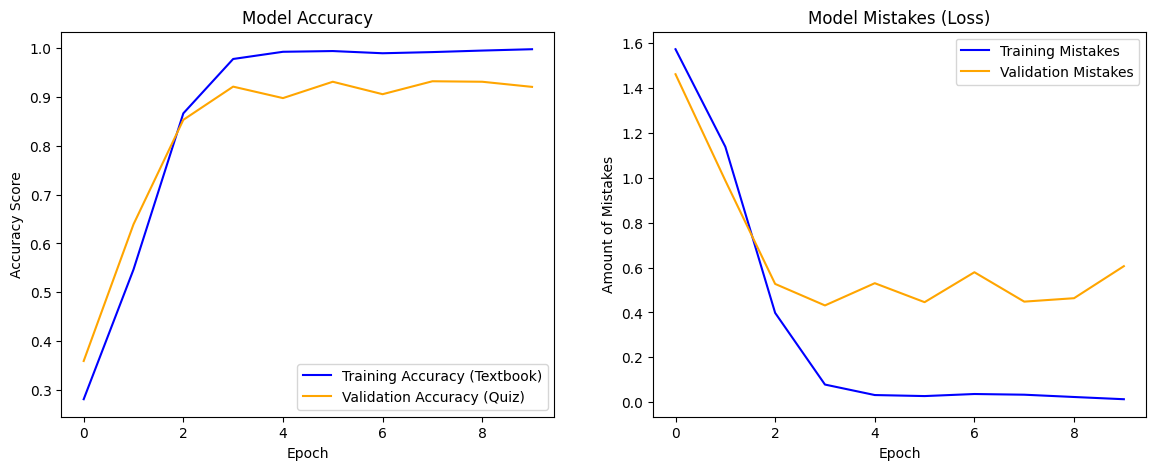

In [22]:
# 4. Draw the Graphs!
plt.figure(figsize=(14, 5))

# Graph A: Accuracy (Higher is better)
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy (Textbook)', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy (Quiz)', color='orange')
plt.title('Model Accuracy')
plt.ylabel('Accuracy Score')
plt.xlabel('Epoch')
plt.legend()

# Graph B: Loss/Mistakes (Lower is better)
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Mistakes', color='blue')
plt.plot(history.history['val_loss'], label='Validation Mistakes', color='orange')
plt.title('Model Mistakes (Loss)')
plt.ylabel('Amount of Mistakes')
plt.xlabel('Epoch')
plt.legend()

plt.show()

In [23]:
import tensorflow as tf
from tensorflow.keras import layers, models

# 1. Setup paths to your specific folders
train_dir = 'data/train'
valid_dir = 'data/valid'
test_dir  = 'data/test'

img_height = 224
img_width = 224
batch_size = 32

# 2. Create the Training Loader
train_ds = tf.keras.utils.image_dataset_from_directory(
  train_dir,
  image_size=(img_height, img_width),
  batch_size=batch_size)

# 3. Create the Validation Loader (The "Practice Quiz")
val_ds = tf.keras.utils.image_dataset_from_directory(
  valid_dir,
  image_size=(img_height, img_width),
  batch_size=batch_size)

# 4. Create the Test Loader (The "Final Exam")
test_ds = tf.keras.utils.image_dataset_from_directory(
  test_dir,
  image_size=(img_height, img_width),
  batch_size=batch_size)

Found 10016 files belonging to 5 classes.
Found 963 files belonging to 5 classes.
Found 478 files belonging to 5 classes.


In [24]:
# ... (Keep your model layers and model.compile from before) ...

# 5. Train the model using the separate validation set
model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=15
)

# 6. The Final Exam!
print("--- Final Evaluation on Test Data ---")
results = model.evaluate(test_ds)
print(f"Test Loss: {results[0]}")
print(f"Test Accuracy: {results[1] * 100}%")

# 7. Save your hard work
model.save('face_shape_model.keras')

Epoch 1/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 177s 564ms/step - accuracy: 0.9855 - loss: 0.0639 - val_accuracy: 0.3416 - val_loss: 6.3217
Epoch 2/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 143s 455ms/step - accuracy: 0.9968 - loss: 0.0126 - val_accuracy: 0.3541 - val_loss: 6.9691
Epoch 3/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 141s 451ms/step - accuracy: 0.9997 - loss: 0.0021 - val_accuracy: 0.3614 - val_loss: 7.4004
Epoch 4/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 148s 474ms/step - accuracy: 0.9996 - loss: 0.0020 - val_accuracy: 0.3583 - val_loss: 7.2272
Epoch 5/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 204s 479ms/step - accuracy: 0.9997 - loss: 0.0013 - val_accuracy: 0.3614 - val_loss: 7.4304
Epoch 6/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 190s 439ms/step - accuracy: 0.9996 - loss: 0.0016 - val_accuracy: 0.3572 - val_loss: 7.4081
Epoch 7/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 146s 465ms/step - accuracy: 0.9996 - loss: 0.0013 - val_accuracy: 0.3572 - val_loss: 7.4127
Epoch 8/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 149s 476ms/step - accuracy: 0.9996 -

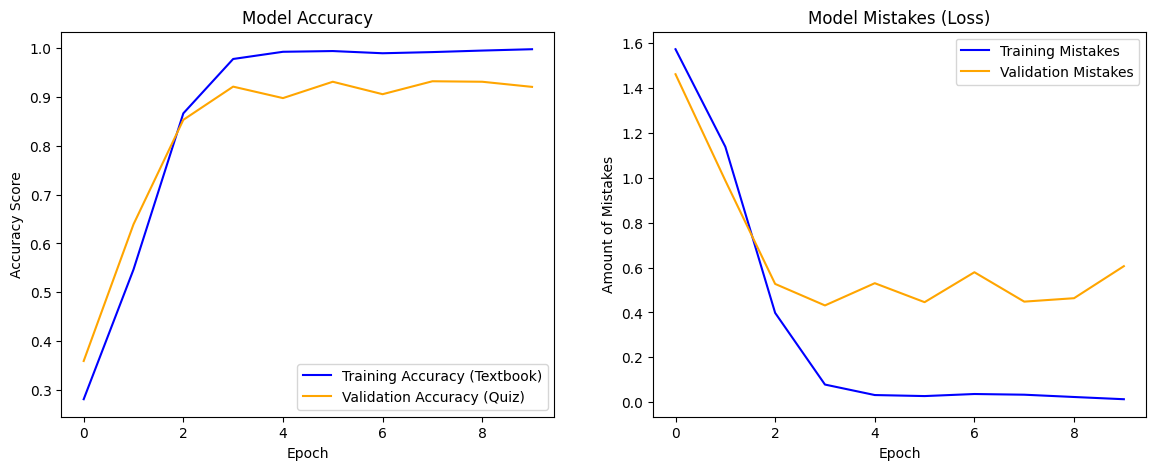

In [25]:
# 4. Draw the Graphs!
plt.figure(figsize=(14, 5))

# Graph A: Accuracy (Higher is better)
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy (Textbook)', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy (Quiz)', color='orange')
plt.title('Model Accuracy')
plt.ylabel('Accuracy Score')
plt.xlabel('Epoch')
plt.legend()

# Graph B: Loss/Mistakes (Lower is better)
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Mistakes', color='blue')
plt.plot(history.history['val_loss'], label='Validation Mistakes', color='orange')
plt.title('Model Mistakes (Loss)')
plt.ylabel('Amount of Mistakes')
plt.xlabel('Epoch')
plt.legend()

plt.show()

In [26]:
import tensorflow as tf
import keras

print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")

TensorFlow version: 2.20.0
Keras version: 3.12.0


In [27]:
import sys
print(sys.version)

3.13.1 (tags/v3.13.1:0671451, Dec  3 2024, 19:06:28) [MSC v.1942 64 bit (AMD64)]
